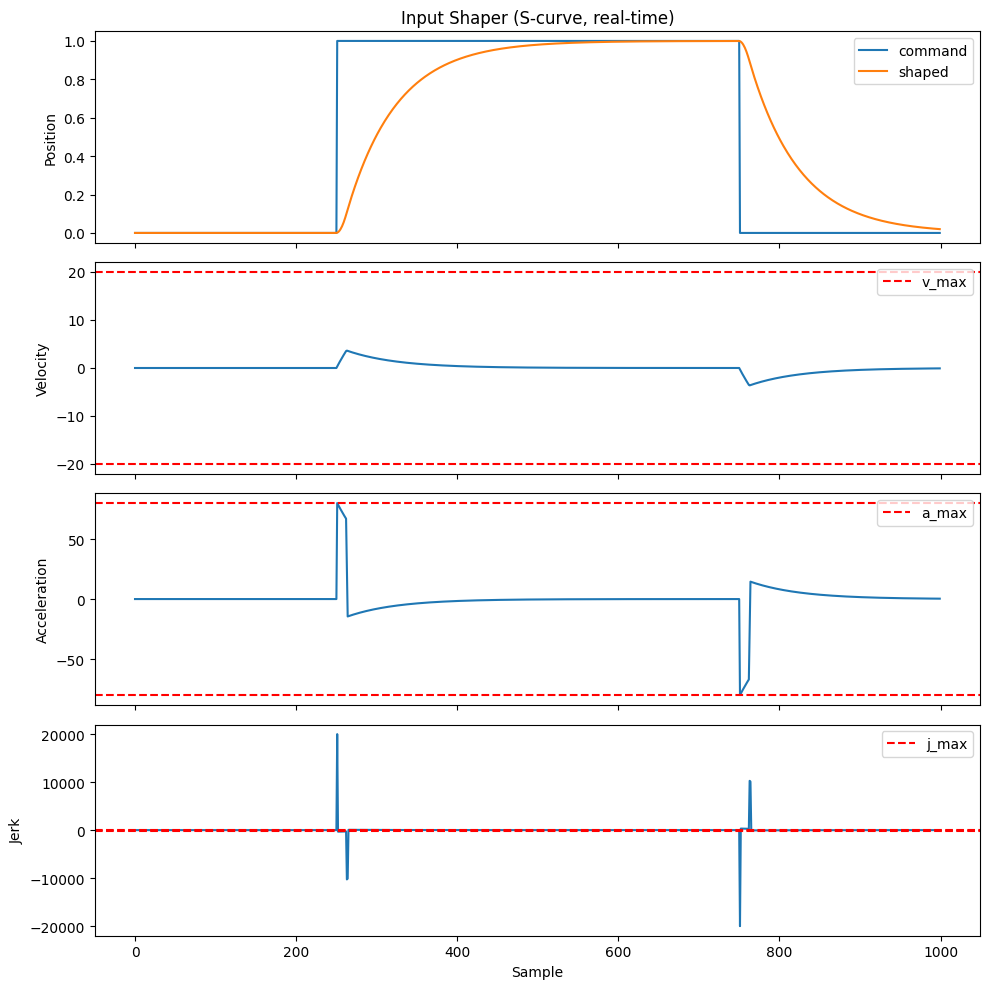

In [24]:
import numpy
import matplotlib.pyplot as plt
dt = 1.0/250.0
num_samples = 1000


x_command = []

for n in range(num_samples):

    if n > num_samples*3/4:
        x = 0.0
    elif n > num_samples/4:
        x = 1.0
    else:
        x = 0.0
    
    x_command.append(x)


x_command = numpy.array(x_command)

v_max = 20.0 #max velocity
a_max = 80.0 #max acceleration
j_max = 100.0 #max jerk



class Shaper:
    """
    Python port of the C++ ShaperS class.
    Two-stage filter:
      1) Ramp limiter: x0 moves toward x_target at most by `ramp` per step
      2) Low-pass:     x1 = (1 - alpha)*x1 + alpha*x0   (S-curve smoothing)
    
    ramp  = v_max * dt   (max position change per sample)
    alpha = a_max * dt / v_max  (smoothing factor, clamped to (0, 1))
    """
    def __init__(self, v_max, a_max, j_max, dt):
        self.v_max  = v_max
        self.a_max  = a_max
        self.j_max  = j_max
        self.dt     = dt

        # ramp = max allowed position change per step
        self.ramp = v_max * dt

        # alpha controls S-curve shape: smaller = smoother
        # derived from acceleration limit relative to velocity limit
        self.alpha = min(a_max * dt / v_max, 1.0)

        # internal states (matching C++ x0, x1)
        self.x0 = 0.0
        self.x1 = 0.0

    def step(self, x_target):
        dif = x_target - self.x0

        # ramp limiter
        if abs(dif) > self.ramp:
            self.x0 += numpy.sign(dif) * self.ramp
        else:
            self.x0 = x_target

        # first-order low-pass (creates the S-curve)
        self.x1 = (1.0 - self.alpha) * self.x1 + self.alpha * self.x0

        return self.x1

    def set(self, value):
        self.x0 = value
        self.x1 = value

    def __call__(self, x_target):
        return self.step(x_target)



shaper = Shaper(v_max, a_max, j_max, dt)
x_shaped = numpy.zeros(num_samples)
v_shaped = numpy.zeros(num_samples)
a_shaped = numpy.zeros(num_samples)
j_shaped = numpy.zeros(num_samples)

for n in range(num_samples):
    x_shaped[n] = shaper(x_command[n])
   


for n in range(num_samples):
    v_shaped[n] = (x_shaped[n] - x_shaped[n-1])/dt if n > 0 else 0.0
    a_shaped[n] = (v_shaped[n] - v_shaped[n-1])/dt if n > 0 else 0.0
    j_shaped[n] = (a_shaped[n] - a_shaped[n-1])/dt if n > 0 else 0.0




fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(x_command, label='command')
axes[0].plot(x_shaped, label='shaped')
axes[0].set_ylabel('Position')
axes[0].legend()
axes[0].set_title('Input Shaper (S-curve, real-time)')

axes[1].plot(v_shaped)
axes[1].axhline(v_max, color='r', ls='--', label='v_max')
axes[1].axhline(-v_max, color='r', ls='--')
axes[1].set_ylabel('Velocity')
axes[1].legend()

axes[2].plot(a_shaped)
axes[2].axhline(a_max, color='r', ls='--', label='a_max')
axes[2].axhline(-a_max, color='r', ls='--')
axes[2].set_ylabel('Acceleration')
axes[2].legend()

axes[3].plot(j_shaped)
axes[3].axhline(j_max, color='r', ls='--', label='j_max')
axes[3].axhline(-j_max, color='r', ls='--')
axes[3].set_ylabel('Jerk')
axes[3].set_xlabel('Sample')
axes[3].legend()

plt.tight_layout()
plt.show()